# Imports

In [10]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import random
import csv
from typing import Tuple

# Import proto-language modules
from proto_language.language.core import (
    Constraint,
    Construct,
    Segment,
    Sequence,
    Program,
)
from proto_language.language.constraint import (
    structure_plddt_constraint,
    structure_ptm_constraint,
    protein_symmetry_ring_constraint,
    protein_globularity_constraint,
    max_homopolymer_constraint,
)
from proto_language.language.optimizer import (
    MCMCOptimizer,
    MCMCOptimizerConfig,
)
from proto_language.language.generator import (
    ESM2Generator,
    ESM2GeneratorConfig,
)

random.seed(42)
np.random.seed(42)

# Write Program

In [11]:
# Configuration parameters
MONOMER_LENGTH = 30
N_SYMMETRIC_UNITS = 3
N_STEPS = 200  # Reduced from 2000 for faster convergence

#######################
## Segments ##
#######################

segment = Segment(
    length=MONOMER_LENGTH,
    sequence_type="protein",
)

################
## Construct ##
################

construct = Construct([segment])

################
## Generator ##
################

# Initialize ESM2 protein language model generator
esm2_gen_config = ESM2GeneratorConfig()
esm2_gen = ESM2Generator(esm2_gen_config)

esm2_gen.assign(segment)

#################
## Constraints ##
#################

# ESMFold pLDDT constraint (protein confidence/quality)
esmfold_plddt = Constraint(
    inputs=[segment for _ in range(N_SYMMETRIC_UNITS)],
    function=structure_plddt_constraint,
    function_config={"structure_tool": "esmfold"},
    weight=20,
)

esmfold_ptm = Constraint(
    inputs=[segment for _ in range(N_SYMMETRIC_UNITS)],
    function=structure_ptm_constraint,
    function_config={"structure_tool": "esmfold"},
    weight=20,
)

symmetry = Constraint(
    inputs=[segment],
    function=protein_symmetry_ring_constraint,
    function_config={
        "n_replications": N_SYMMETRIC_UNITS,
        "all_to_all_protomer_symmetry": True,
    },
)

globularity = Constraint(
    inputs=[segment],
    function=protein_globularity_constraint,
    function_config={"n_replications": N_SYMMETRIC_UNITS},
)

homopolymer = Constraint(
    inputs=[segment],
    function=max_homopolymer_constraint,
    function_config={"max_length": 2},
    weight=20,
)

#############
## Optimizer & Program ##
#############

def custom_logging(step: int, outputs: Tuple[Segment]) -> None:
    output_sequence: Sequence = outputs[0].selected_sequences[0]
    metakeys = list(output_sequence._metadata.keys())
    folded_sequence = output_sequence._metadata.get(
        next((key for key in metakeys if key.endswith('esmfolded_sequence')), 'esmfolded_sequence'),
        output_sequence._sequence
    )
    plddt = output_sequence._metadata.get(
        next((key for key in metakeys if key.endswith('avg_plddt')), 'avg_plddt'),
        'N/A'
    )
    ptm = output_sequence._metadata.get(
        next((key for key in metakeys if key.endswith('ptm')), 'ptm'),
        'N/A'
    )
    print(
        f"Iteration {step} | "
        f"sequence (real): {output_sequence._sequence}, "
        f"sequence: {folded_sequence}, "
        f"pLDDT: {plddt}, "
        f"pTM: {ptm}"
    )


mcmc_optimizer_config = MCMCOptimizerConfig(
    num_selected=1,
    mcmc_width=1,
    num_steps=N_STEPS,
    max_temperature=1.0,  # Reduced from 2.0 for faster convergence (more greedy)
    min_temperature=0.01,  # Increased from 0.0001 for faster convergence
    track_step_size=1,  # Changed from 100 to log every step
    verbose=True,
)

# Create optimizer
optimizer = MCMCOptimizer(
    constructs=[construct],
    generators=[esm2_gen],
    constraints=[
        esmfold_plddt,
        esmfold_ptm,
        symmetry,
        globularity,
        homopolymer,
    ],
    config=mcmc_optimizer_config,
    custom_logging=custom_logging,
)

# Create program with optimizer
program = Program(
    optimizers=[optimizer],
)

# Run Program

In [12]:
program.run()
print(f"Generated {len(optimizer.history)} sequence snapshots during optimization")
# History is a list of dictionaries with keys: "time_step", "energy_scores", "constructs"
initial_construct = optimizer.history[0]["constructs"][0]
final_construct = program.constructs[0]


Energy Scoring: 0 filters, 5 scoring constraints
Formula: energy = Σ(weight_i x constraint_score_i)

Constraint 1: structure_plddt_constraint
Local GPU not available, falling back to cloud
  Candidate 0: 14.3416 = 0.7171 * 20
Constraint 2: structure_ptm_constraint
  Candidate 0: 16.9280 = 0.8464 * 20
Constraint 3: protein_symmetry_ring_constraint
  Candidate 0: 0.0431
Constraint 4: protein_globularity_constraint
  Candidate 0: 4.5133
Constraint 5: max_homopolymer_constraint
  Candidate 0: 0.0000 = 0.0000 * 20
Final Energy Scores:
  Candidate 0: 35.8261
Initial state for optimizer 1:
  [0] Energy: 35.8261
    Construct 0: VDMGGAVTHYEQDHFGSCDTFTEGRYMDIE

Energy Scoring: 0 filters, 5 scoring constraints
Formula: energy = Σ(weight_i x constraint_score_i)

Constraint 1: structure_plddt_constraint
  Candidate 0: 14.3416 = 0.7171 * 20
Constraint 2: structure_ptm_constraint
  Candidate 0: 16.9280 = 0.8464 * 20
Constraint 3: protein_symmetry_ring_constraint
  Candidate 0: 0.0431
Constraint 4: 

# Save Metadata

In [13]:
metadata = final_construct.joined_sequences[0]._metadata
print(metadata)

# Save metadata to CSV (create directory if needed)
import os
os.makedirs('metadata_examples', exist_ok=True)
with open('metadata_examples/esm2_example_metadata.csv', 'w') as f:
    writer = csv.DictWriter(f, fieldnames=metadata.keys())
    writer.writeheader()
    writer.writerow(metadata)

{'segment_0.structure_plddt_constraint.avg_plddt': 0.7298230528831482, 'segment_0.structure_plddt_constraint.pdb_output': 'ATOM      1  N   GLY A   1      -9.544 -20.826 -21.133  1.00  0.38          N  \nATOM      2  CA  GLY A   1     -10.289 -19.885 -20.311  1.00  0.36          C  \nATOM      3  C   GLY A   1      -9.434 -18.751 -19.778  1.00  0.39          C  \nATOM      4  O   GLY A   1      -9.853 -17.592 -19.790  1.00  0.37          O  \nATOM      5  N   ALA A   2     -10.904 -20.401 -20.065  1.00  0.48          N  \nATOM      6  CA  ALA A   2      -9.738 -19.779 -19.442  1.00  0.48          C  \nATOM      7  C   ALA A   2     -10.053 -19.329 -18.018  1.00  0.48          C  \nATOM      8  CB  ALA A   2      -9.256 -18.595 -20.277  1.00  0.44          C  \nATOM      9  O   ALA A   2      -9.236 -19.503 -17.111  1.00  0.46          O  \nATOM     10  N   VAL A   3      -9.405 -20.024 -18.300  1.00  0.55          N  \nATOM     11  CA  VAL A   3      -9.620 -19.607 -16.918  1.00  0.55 

# Visualize Results

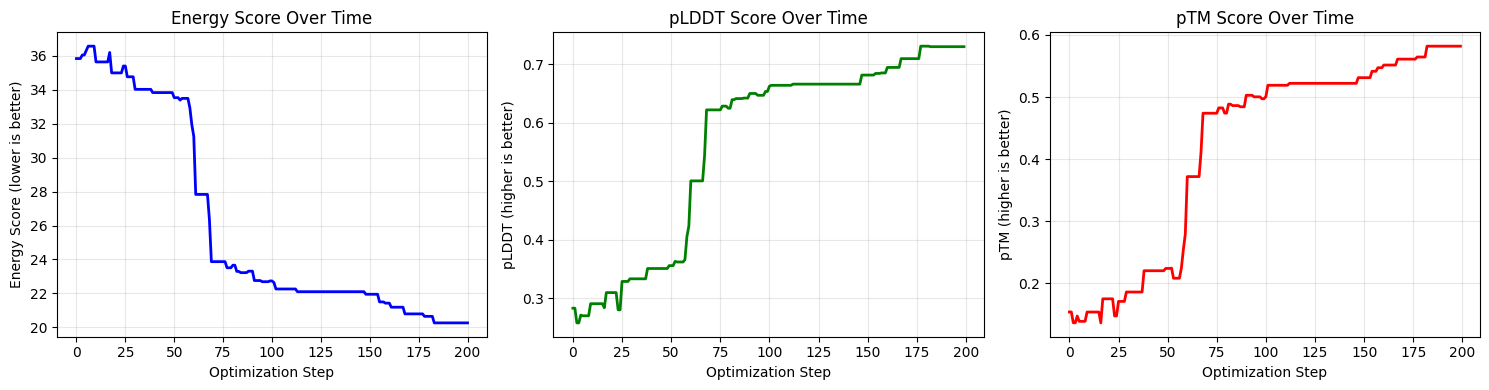


Optimization Summary:
Initial sequence: VDMGGAVTHYEQDHFGSCDTFTEGRYMDIE
Final sequence:   GAVDGVVTRYDWDLAGRMVRRTETRTSGAG
Energy improvement: 35.826 → 20.269
pLDDT improvement:  0.283 → 0.730
pTM improvement:    0.154 → 0.582

Final protein will form a 3-fold symmetric ring structure


In [16]:
# Extract metrics from history - handle different metadata key formats
def get_metric(metadata, metric_name):
    """Get metric from metadata, handling suffixed keys."""
    if metric_name in metadata:
        return metadata[metric_name]
    for key in metadata.keys():
        if key.endswith(metric_name):
            return metadata[key]
    return None

# History is a list of dictionaries with keys: "time_step", "energy_scores", "constructs"
energy_scores = [c["energy_scores"][0] for c in optimizer.history]
plddt_scores = [get_metric(c["constructs"][0].joined_sequences[0]._metadata, 'avg_plddt') for c in optimizer.history]
ptm_scores = [get_metric(c["constructs"][0].joined_sequences[0]._metadata, 'ptm') for c in optimizer.history]

# Filter out None values for plotting
energy_scores = [e for e in energy_scores if e is not None]
plddt_scores = [p for p in plddt_scores if p is not None]
ptm_scores = [p for p in ptm_scores if p is not None]

# Plot optimization progress
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Energy score plot
if energy_scores:
    axes[0].plot(energy_scores, 'b-', linewidth=2)
    axes[0].set_title('Energy Score Over Time')
    axes[0].set_xlabel('Optimization Step')
    axes[0].set_ylabel('Energy Score (lower is better)')
    axes[0].grid(True, alpha=0.3)

# pLDDT score plot
if plddt_scores:
    axes[1].plot(plddt_scores, 'g-', linewidth=2)
    axes[1].set_title('pLDDT Score Over Time')
    axes[1].set_xlabel('Optimization Step')
    axes[1].set_ylabel('pLDDT (higher is better)')
    axes[1].grid(True, alpha=0.3)

# pTM score plot
if ptm_scores:
    axes[2].plot(ptm_scores, 'r-', linewidth=2)
    axes[2].set_title('pTM Score Over Time')
    axes[2].set_xlabel('Optimization Step')
    axes[2].set_ylabel('pTM (higher is better)')
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\nOptimization Summary:")
print(f"Initial sequence: {initial_construct.joined_sequences[0]._sequence}")
print(f"Final sequence:   {final_construct.joined_sequences[0]._sequence}")

if energy_scores:
    print(f"Energy improvement: {energy_scores[0]:.3f} → {energy_scores[-1]:.3f}")
if plddt_scores:
    print(f"pLDDT improvement:  {plddt_scores[0]:.3f} → {plddt_scores[-1]:.3f}")
if ptm_scores:
    print(f"pTM improvement:    {ptm_scores[0]:.3f} → {ptm_scores[-1]:.3f}")

print(f"\nFinal protein will form a {N_SYMMETRIC_UNITS}-fold symmetric ring structure")


In [18]:
import py3Dmol

def visualize_structure_in_notebook(sequence: Sequence):
    """
    Visualize protein structure directly in Jupyter notebook using py3Dmol.
    This works without requiring PyMOL installation.
    """        
    pdb_content = get_metric(sequence._metadata, 'pdb_output')
    if pdb_content is None:
        print("No PDB structure available in metadata")
        return None
    
    # Create 3D viewer
    viewer = py3Dmol.view(width=800, height=600)
    
    # Add the structure
    viewer.addModel(pdb_content, 'pdb')
    
    # Style the structure
    viewer.setStyle({'cartoon': {'color': 'spectrum'}})
    
    # If it's a multimer, color chains differently
    chains = set()
    for line in pdb_content.split('\n'):
        if line.startswith('ATOM'):
            chain = line[21]
            chains.add(chain)
    
    if len(chains) > 1:
        colors = ['red', 'blue', 'green', 'yellow', 'orange', 'purple', 'cyan', 'magenta']
        for i, chain in enumerate(sorted(chains)):
            color = colors[i % len(colors)]
            viewer.setStyle({'chain': chain}, {'cartoon': {'color': color}})
    
    # Center and zoom
    viewer.zoomTo()
    
    plddt = get_metric(sequence._metadata, 'avg_plddt')
    ptm = get_metric(sequence._metadata, 'ptm')
    print(f"pLDDT: {plddt:.3f}" if plddt else "pLDDT: N/A")
    print(f"pTM: {ptm:.3f}" if ptm else "pTM: N/A")
    print(f"Sequence: {sequence.sequence}")
    return viewer


print("Initial Structure")
# Note: For initial construct, metadata is in candidate_sequences (not selected_sequences)
# because the snapshot was taken before the first MH acceptance step copied candidates to selected
initial_viewer = visualize_structure_in_notebook(initial_construct.segments[0].candidate_sequences[0])
if initial_viewer:
    initial_viewer.show()

print("\nFinal Structure")
final_viewer = visualize_structure_in_notebook(final_construct.joined_sequences[0])
if final_viewer:
    final_viewer.show()

Initial Structure
pLDDT: 0.283
pTM: 0.154
Sequence: VDMGGAVTHYEQDHFGSCDTFTEGRYMDIE


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


Final Structure
pLDDT: 0.730
pTM: 0.582
Sequence: GAVDGVVTRYDWDLAGRMVRRTETRTSGAG


3Dmol.js failed to load for some reason. Please check your browser console for error messages.